In [ ]:
import json
from pathlib import Path

DATA_NAME = "SLEEP"  # "MDD", "SEED", "SLEEP", "CHINESE", "BCIC2A"
DATA_ROOT = Path("course project")
DATA_DIR = DATA_ROOT / DATA_NAME

if DATA_NAME == "SLEEP":
    MODEL_NAME = "sleep_ctnet"  # "sleep_ctnet", "gru", "lstm"
else:
    MODEL_NAME = "lstm"  # "sleep_ctnet", "gru", "lstm"

BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.0
SEED = 42
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"
CHECKPOINT_DIR = Path("checkpoints")
RUN_NAME = f"{DATA_NAME.lower()}_{MODEL_NAME}_notebook"

# 依次尝试 dataset_info.json / dataset_info_fixed.json
candidate_info_files = [
    DATA_DIR / "dataset_info.json",
    DATA_DIR / "dataset_info_fixed.json",
]
DATA_INFO_PATH = next((p for p in candidate_info_files if p.exists()), candidate_info_files[0])

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Dataset:", DATA_NAME)
print("Model:", MODEL_NAME)
print("Categories:", category_list)
print("Number of classes", len(category_list))
CLASSES = len(category_list)
print("Channels (count):", len(channels))
CHANNELS = len(channels)
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)
print("Device:", DEVICE)



=== Dataset Intro ===
Dataset: MDD
Model: sleep_ctnet
Categories: ['Healthy Controls', 'Major Depressive Disorder']
Number of classes 2
Channels (count): 20
Channels: ['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Cz', 'Pz', 'A2-A1']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 1.0
Device: cpu


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [14]:
import h5py
import numpy as np

INDEX_PATH_TRAIN = DATA_DIR / "train.h5"
INDEX_PATH_VAL = DATA_DIR / "val.h5"
INDEX_PATH_TEST = DATA_DIR / "test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

keys: ['X', 'y']
x dtype: float32
x shape: (960, 20, 200)
y dtype: int64
y shape: (960,)
unique: [0 1]


## 2) 定义模型：SimpleLinear
最简单的线性分类器，方便和更复杂模型对比。


In [15]:
import torch
import torch.nn as nn

class SimpleLinear(nn.Module):
    def __init__(self, input_channels, time_points, num_classes):
        super(SimpleLinear, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_channels * time_points, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


## 3) 定义模型：SimpleMLP
把输入拉平后通过多层全连接网络进行分类，表达能力比线性模型更强。


In [16]:
class SimpleMLP(nn.Module):
    def __init__(
        self,
        input_channels,
        time_points=200,
        num_classes=len(category_list),
        hidden_dims=(256, 128),
        dropout=0.3
    ):
        super().__init__()

        input_dim = input_channels * time_points

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, C, T)
        x = self.flatten(x)      # -> (B, C*T)
        logits = self.mlp(x)     # -> (B, num_classes)
        return logits

## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


In [17]:
class EEGNet(nn.Module):  # EEGNet-8,2
    def __init__(self, chans,time_point=200,f1=8, d=2, pk1=4, pk2=8, dp=0.5, max_norm1=1,norm=torch.nn.Identity()):
        super(EEGNet, self).__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(f1),
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # Depthwise Conv
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0,8)),  # Separable Conv
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),  # Pointwise Conv
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        self._apply_max_norm(self.block2[0], max_norm1)
        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.norm=norm


    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        self.norm(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(dim=1)
        x = self.block1(x.unsqueeze(dim=1))
        x = self.block2(x)
        x = self.block3(x)
        return x.flatten(start_dim=1)

## 5) 导入模型：EEGLSTM和EEGGRU
导入LSTM和GRU，并分析其训练效果如何


In [18]:
import copy
from argparse import Namespace

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from TEST_DATASET import TrainDataset, TestDataset
from eeg_pipeline import build_model, set_seed

set_seed(SEED)

MODEL_ARGS = Namespace(
    model=MODEL_NAME,
    hidden_dim=64,
    num_layers=2,
    unidirectional=False,
    dropout=0.3,
    grad_clip=1.0,
    emb_size=64,
    depth=4,
    num_heads=4,
    temporal_filters=16,
    depth_multiplier=2,
    kernel_size=64,
    pool_size_1=8,
    pool_size_2=8,
    mlp_ratio=2,
)

train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model = build_model(MODEL_NAME, CHANNELS, CLASSES, MODEL_ARGS).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print("Train shape:", tuple(train_ds.x.shape))
print("Val shape:", tuple(val_ds.x.shape))
print("Test shape:", tuple(test_ds.x.shape))
print(model)



Train shape: (960, 20, 200)
Val shape: (640, 20, 200)
Test shape: (800, 20, 200)
CTNetClassifier(
  (embedding): ConvPatchEmbedding(
    (temporal): Sequential(
      (0): Conv2d(1, 16, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (spatial): Sequential(
      (0): Conv2d(16, 32, kernel_size=(20, 1), stride=(1, 1), groups=16, bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ELU(alpha=1.0)
      (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
      (4): Dropout(p=0.3, inplace=False)
    )
    (projection): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ELU(alpha=1.0)
      (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
      (4): Dropout(p=0

## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


Epoch [01/50] | Train Loss: 0.5803 | Train Acc: 0.6937 | Val Loss: 0.3870 | Val Acc: 0.8375
Epoch [02/50] | Train Loss: 0.4498 | Train Acc: 0.7948 | Val Loss: 0.3722 | Val Acc: 0.8641
Epoch [03/50] | Train Loss: 0.4275 | Train Acc: 0.8135 | Val Loss: 0.3431 | Val Acc: 0.8734
Epoch [04/50] | Train Loss: 0.4029 | Train Acc: 0.8073 | Val Loss: 0.3386 | Val Acc: 0.8703
Epoch [05/50] | Train Loss: 0.3762 | Train Acc: 0.8479 | Val Loss: 0.3595 | Val Acc: 0.8578
Epoch [06/50] | Train Loss: 0.3470 | Train Acc: 0.8583 | Val Loss: 0.3955 | Val Acc: 0.8594
Epoch [07/50] | Train Loss: 0.3515 | Train Acc: 0.8458 | Val Loss: 0.3751 | Val Acc: 0.8734
Epoch [08/50] | Train Loss: 0.3359 | Train Acc: 0.8521 | Val Loss: 0.3925 | Val Acc: 0.8625
Epoch [09/50] | Train Loss: 0.3279 | Train Acc: 0.8521 | Val Loss: 0.3869 | Val Acc: 0.8828
Epoch [10/50] | Train Loss: 0.3114 | Train Acc: 0.8688 | Val Loss: 0.3376 | Val Acc: 0.8812
Epoch [11/50] | Train Loss: 0.2971 | Train Acc: 0.8729 | Val Loss: 0.3969 | Val 

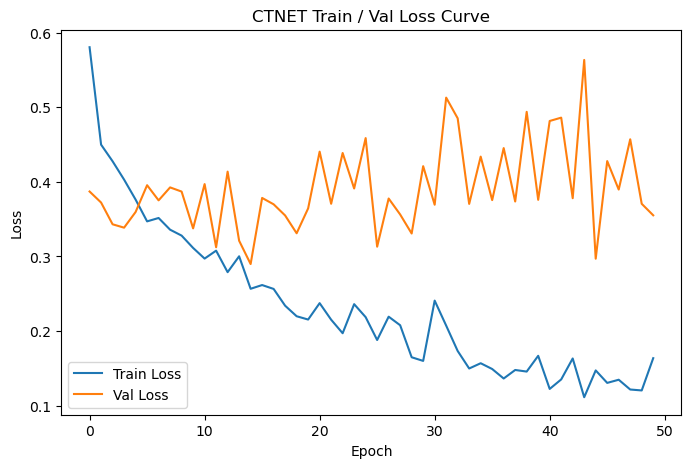

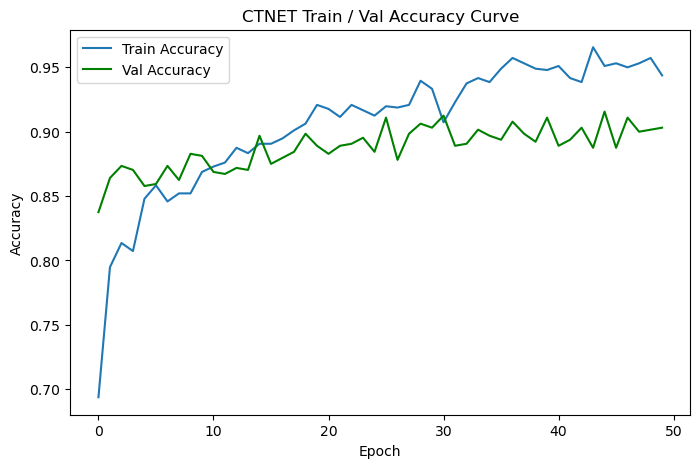

In [19]:
# -------------------------
# 训练 / 验证，并保存最佳 checkpoint
# -------------------------
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = -1.0
best_epoch = -1
best_state = None

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / f"{RUN_NAME}.pt"
HISTORY_PATH = CHECKPOINT_DIR / f"{RUN_NAME}_history.json"

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_num = 0

    for data, label in train_loader:
        data = data.to(DEVICE)
        label = label.to(DEVICE)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()

        if hasattr(model, "clip_gradients"):
            model.clip_gradients()
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_correct += (torch.argmax(output, dim=1) == label).sum().item()
        train_num += batch_size

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data = val_data.to(DEVICE)
            val_label = val_label.to(DEVICE)

            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_correct += (torch.argmax(val_output, dim=1) == val_label).sum().item()
            val_num += batch_size

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(
            {
                "model_name": MODEL_NAME,
                "model_state": best_state,
                "dataset": DATA_NAME,
                "num_classes": CLASSES,
                "channels": CHANNELS,
                "category_list": category_list,
                "args": vars(MODEL_ARGS),
                "best_epoch": best_epoch,
                "best_val_acc": best_val_acc,
            },
            CHECKPOINT_PATH,
        )

with open(HISTORY_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "dataset": DATA_NAME,
            "model": MODEL_NAME,
            "best_epoch": best_epoch,
            "best_val_acc": best_val_acc,
            "train_losses": train_losses,
            "train_accuracies": train_accuracies,
            "val_losses": val_losses,
            "val_accuracies": val_accuracies,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print("\n" + "-" * 40)
print(f"Best Val Accuracy: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"Checkpoint saved to: {CHECKPOINT_PATH}")
print(f"History saved to: {HISTORY_PATH}")

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{MODEL_NAME.upper()} Train / Val Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_NAME.upper()} Train / Val Accuracy Curve")
plt.legend()
plt.show()




## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [20]:
# -------------------------
# 加载最佳模型并生成 test 预测标签
# -------------------------
if best_state is None:
    raise RuntimeError("No trained model found. Please run the training cell first.")

model.load_state_dict(best_state)
model.eval()
output_path = DATA_DIR / f"{DATA_NAME}.txt"

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:
        test_data = test_data.to(DEVICE)
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")
print(f"Best checkpoint reused from: {CHECKPOINT_PATH}")




Saved 800 labels to: course project/MDD/MDD.txt
Best checkpoint reused from: checkpoints/mdd_sleep_ctnet_notebook.pt
